# Objective: Prediction of Individual's Credit Worthiness using Past Data

In [34]:
import pandas as pd 
import numpy as np
df=pd.read_csv("credit_risk_dataset.csv")
#First Five Rows
print(df.head())
#Shape of Dataset
print(df.shape)
#Dataset Columns
print(df.columns.tolist())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


# Now Get Info and Null Values of Dataset

In [35]:
# info about dataset
print(f'Dataset Info: {df.info()}')
# Missing  Values
print(f'Null Values in Dataset {df.isnull().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
Dataset Info: None
Null Values in Dataset pers

# Remove Null Values from numerical columns

In [36]:
# To remove null values from Numerical columns we will use median to fill these Null Values.
Numerical_Cols=['person_emp_length','loan_int_rate']
for col in Numerical_Cols:
    df[col]=df[col].fillna(df[col].median())

# Now check Null Values Again
print(df.isnull().sum())
print(df.columns.tolist())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


# Exploratory Data Analysis (EDA)

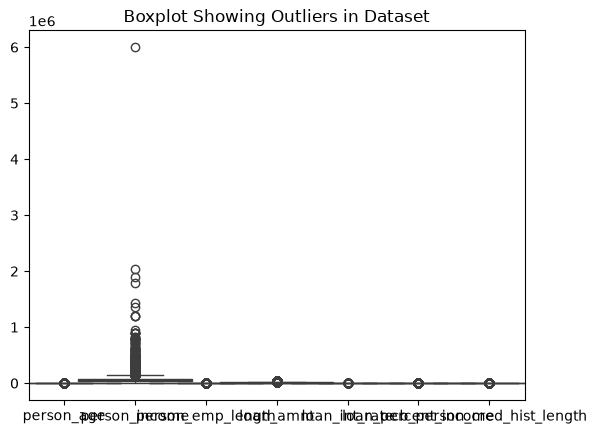

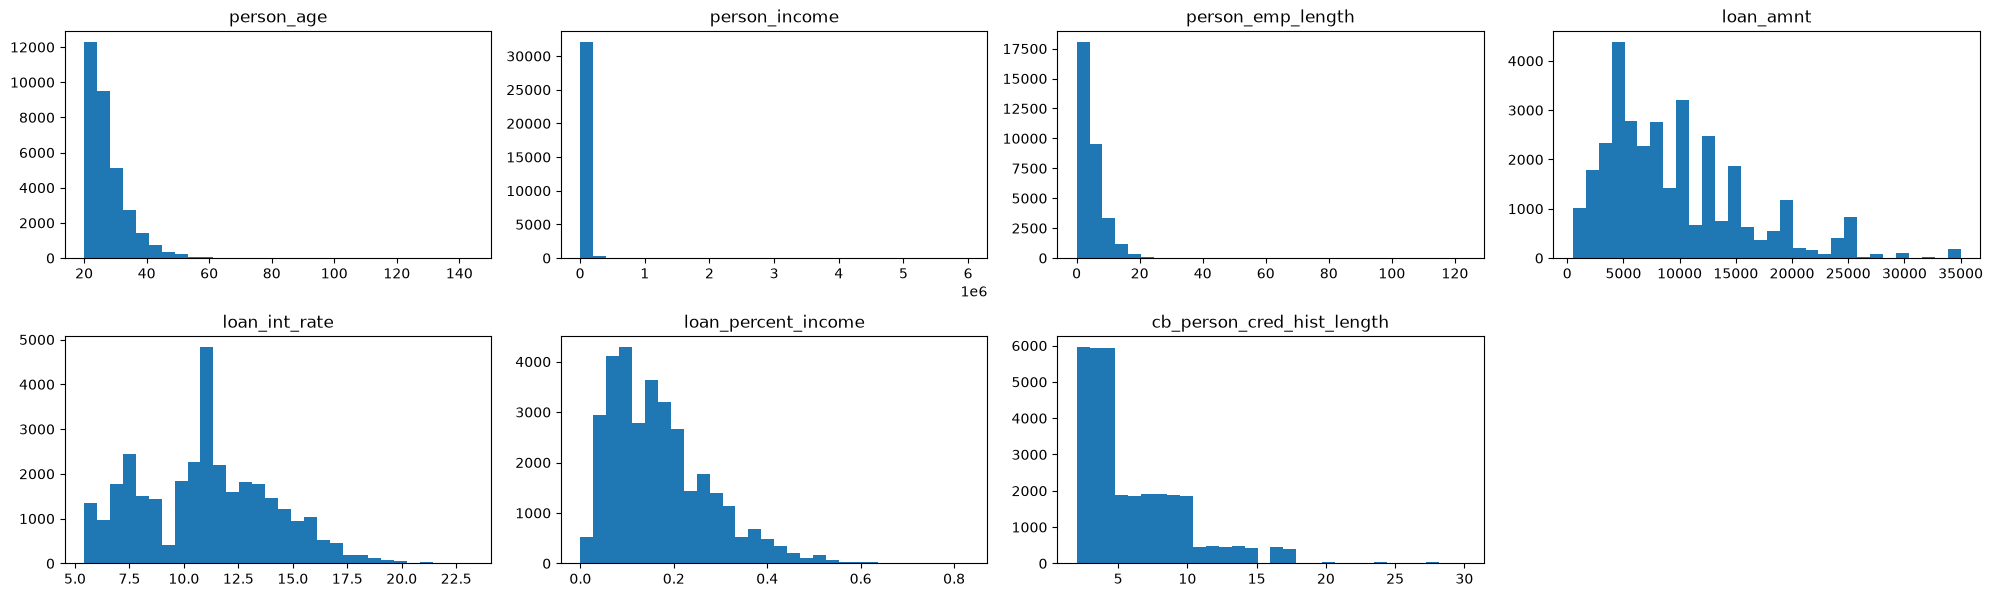

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.Figure(figsize=(15,8))
# To check outliers in Numerical Columns we will use Boxplot to check outliers in Data.
# Numerical_Columns=['person_age', 'person_income','person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income','cb_person_cred_hist_length']
sns.boxplot(data=df[['person_age', 'person_income','person_emp_length', 'loan_amnt', 'loan_int_rate','loan_percent_income','cb_person_cred_hist_length']],gap=3)
plt.title('Boxplot Showing Outliers in Dataset')
plt.show()

# Now Draw Frequency Distribution to check Which Outlier Removal Technique should b used to remove Outliers from Data
Allcolumns=df[['person_age', 'person_income','person_emp_length', 'loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']]
Allcolumns.hist(bins=30,grid=False,figsize=(20,15),layout=(5,4),)
plt.tight_layout()
plt.show()



# Now Remove Outliers using InterQuartileRange (IQR) Method

In [38]:
def handle_outliers(df,col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    #Now Calculate InterQuartileRange
    IQR=Q3-Q1

    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    df[col]=df[col].clip(lower_bound,upper_bound)
    return df
Numerical_Columns=['person_age', 'person_income','person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income','cb_person_cred_hist_length']
for col in Numerical_Columns:
    df=handle_outliers(df,col)

# Now Again check if any Outlier Exist in Dataset

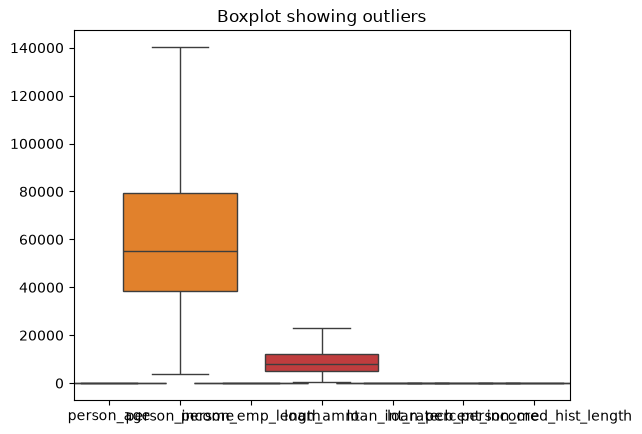

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
# Numerical_Columns=['person_age', 'person_income','person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income','cb_person_cred_hist_length']
plt.Figure(figsize=(15,8))

sns.boxplot(data=df[['person_age', 'person_income','person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income','cb_person_cred_hist_length']],gap=3)
plt.title("Boxplot showing outliers")
plt.show()
print(df.columns.tolist())

In [40]:
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


# Now Perform Encoding for Categorical Columns

In [41]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
# Perform Ordinal Encoding for loan_grade 
grade_maping={'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6,'H':7}
df['loan_grade']=df['loan_grade'].map(grade_maping)

## 2. Binary Encoding for 'cb_person_default_on_file'
cb_person_maping={'Y':1,'N':0}
df['cb_person_default_on_file']=df['cb_person_default_on_file'].map(cb_person_maping)

# # now we are going to apply one Hot Encoding on Nominal Columns 
# # (Nominal are columns which donot have any order or Ranking)

# df=pd.get_dummies(df,columns=['person_home_ownership', 'loan_intent'],drop_first=True)

#Now View First Five Rows
print(df.head())


   person_age  person_income person_home_ownership  person_emp_length  \
0        22.0          59000                  RENT               14.5   
1        21.0           9600                   OWN                5.0   
2        25.0           9600              MORTGAGE                1.0   
3        23.0          65500                  RENT                4.0   
4        24.0          54400                  RENT                8.0   

  loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL           3      23000          16.02            1   
1   EDUCATION           1       1000          11.14            0   
2     MEDICAL           2       5500          12.87            1   
3     MEDICAL           2      23000          15.23            1   
4     MEDICAL           2      23000          14.27            1   

   loan_percent_income  cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.44                          1                       

In [ ]:
# # now we are going to apply one Hot Encoding on Nominal Columns 
# # (Nominal are columns which donot have any order or Ranking)

df=pd.get_dummies(df,columns=['person_home_ownership', 'loan_intent'],drop_first=True)


In [43]:
print(df.isnull().sum())

person_age                     0
person_income                  0
person_emp_length              0
loan_grade                     0
loan_amnt                      0
loan_int_rate                  0
loan_status                    0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
person_home_ownership_OTHER    0
person_home_ownership_OWN      0
person_home_ownership_RENT     0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
dtype: int64


# AFter One Hot Encoding some columns are still in 'True/False' state . Logistic regression needs to convert these into 1 and 0 . So convert . 

In [45]:
df=df.replace({True:1,False:0})
print(df.head())
print(df.columns.tolist())
print(df.isnull().sum())

   person_age  person_income  person_emp_length  loan_grade  loan_amnt  \
0        22.0          59000               14.5           3      23000   
1        21.0           9600                5.0           1       1000   
2        25.0           9600                1.0           2       5500   
3        23.0          65500                4.0           2      23000   
4        24.0          54400                8.0           2      23000   

   loan_int_rate  loan_status  loan_percent_income  cb_person_default_on_file  \
0          16.02            1                 0.44                          1   
1          11.14            0                 0.10                          0   
2          12.87            1                 0.44                          0   
3          15.23            1                 0.44                          0   
4          14.27            1                 0.44                          1   

   cb_person_cred_hist_length person_home_ownership_OTHER  \
0      

# Now Select Features for Model X,y

In [46]:
X=df[['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']]
y=df['loan_status']

# Now Separate Data between Training and Testing

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
scaler=StandardScaler()
#Now Fit and Transform the Training Data First
X_train_scaled=scaler.fit_transform(X_train)
#Now only Transform Testing Data
X_test_scaled=scaler.transform(X_test)

# Now train model using Logistic Regression 
lr_model=LogisticRegression()
lr_model.fit(X_train_scaled,y_train)
# lr_model.predict([[22, 59000, 14.5, 3, 23000, 16.02, 0.44, 1, 3.0, 0, 0, 1, 0, 0, 0, 1, 0]])


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

array([0])

In [ ]:
#checking predictions after training.

# Now check Metrics of Logistic Regression Model

In [56]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,confusion_matrix,roc_auc_score,precision_score

y_pred=lr_model.predict(X_test_scaled)
precision=precision_score(y_test,y_pred)
print(f'Precision of Model using Logistic Regression: {precision}')
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy of Model using Logistic Regression: {accuracy}')
recall=recall_score(y_test,y_pred)
print(f'Recall of Model using Logistic Regression: {recall}')
f1score=f1_score(y_test,y_pred)
print(f'f1-score of Model using Logistic Regression: {f1score}')
# 3. ROC-AUC Score (Needs probabilities, not just 0 or 1)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")


Precision of Model using Logistic Regression: 0.7358490566037735
Accuracy of Model using Logistic Regression: 0.8529923273657289
Recall of Model using Logistic Regression: 0.5231267345050878
f1-score of Model using Logistic Regression: 0.6115166261151662
ROC-AUC Score: 0.87


# Now Train Model using Decision Trees 

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score,accuracy_score,recall_score,f1_score,roc_auc_score

dt_model=DecisionTreeClassifier(max_depth=5,random_state=42)
dt_model.fit(X_train_scaled,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [94]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,confusion_matrix,roc_auc_score,precision_score
newpred=dt_model.predict([[22, 59000, 14.5, 3, 23000, 16.02, 0.44, 1, 3.0, 0, 0, 1, 0, 0, 0, 1, 0]])
print('First prediction',newpred.tolist())
newpred1=dt_model.predict([[24, 500, 8.0, 2, 1000, 14.27, 0.44, 1, 4.0, 0, 0, 1, 0, 0, 1, 0, 0]])
print('Second prediction',newpred1.tolist())
y_pred=dt_model.predict(X_test_scaled)
precision=precision_score(y_test,y_pred)
print(f'Precision of Model using Decision Tree: {precision}')
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy of Model using Decision Tree: {accuracy}')
recall=recall_score(y_test,y_pred)
print(f'Recall of Model using Decision Tree: {recall}')
f1score=f1_score(y_test,y_pred)
print(f'f1-score of Model using Decision Tree: {f1score}')
# 3. ROC-AUC Score (Needs probabilities, not just 0 or 1)
y_prob = dt_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")


First prediction [0]
Second prediction [1]
Precision of Model using Decision Tree: 0.942560553633218
Accuracy of Model using Decision Tree: 0.9096675191815857
Recall of Model using Decision Tree: 0.6299722479185939
f1-score of Model using Decision Tree: 0.7551982256723039
ROC-AUC Score: 0.89


# Now Train Model using Random Forest 

In [93]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred = rf_model.predict(X_test_scaled)
newpred=rf_model.predict([[22, 59000, 14.5, 3, 23000, 16.02, 0.44, 1, 3.0, 0, 0, 1, 0, 0, 0, 1, 0]])
print('First prediction',newpred.tolist())
newpred1=rf_model.predict([[24, 500, 8.0, 2, 1000, 14.27, 0.44, 1, 4.0, 0, 0, 1, 0, 0, 1, 0, 0]])
print('Second prediction',newpred1.tolist())


First prediction [0]
Second prediction [1]


# Now  Evaluate training of  Random Forest Algorithm using metrics

In [60]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,confusion_matrix,roc_auc_score,precision_score
precision=precision_score(y_test,y_pred)
print(f'Precision of Model using Random Forest: {precision}')
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy of Model using Random Forest: {accuracy}')
recall=recall_score(y_test,y_pred)
print(f'Recall of Model using Random Forest: {recall}')
f1score=f1_score(y_test,y_pred)
print(f'f1-score of Model using Random Forest: {f1score}')
# 3. ROC-AUC Score (Needs probabilities, not just 0 or 1)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")


Precision of Model using Random Forest: 0.9659020458772474
Accuracy of Model using Random Forest: 0.9325831202046035
Recall of Model using Random Forest: 0.7206290471785384
f1-score of Model using Random Forest: 0.8254304635761589
ROC-AUC Score: 0.94


# Now We are going to save our Three models e.g Logistic, Decision Trees and Random Forest

In [61]:
import os
import joblib

joblib.dump(lr_model,"lr_model.joblib")
joblib.dump(dt_model,"dt_model.joblib")
joblib.dump(rf_model,"rf_model.joblib")


['rf_model.joblib']

# Now Load models for use 

In [62]:
LogisticUsage=joblib.load("lr_model.joblib")
DecisionTreeUsage=joblib.load("dt_model.joblib")
RfUsage=joblib.load("rf_model.joblib")

In [91]:
import joblib

# 1. Define your data
samples = [
    [22, 59000, 14.5, 3, 23000, 16.02, 0.44, 1, 3.0, 0, 0, 1, 0, 0, 0, 1, 0],
    [21, 9600, 5.0, 1, 1000, 11.14, 0.10, 0, 2.0, 0, 1, 0, 1, 0, 0, 0, 0],
    [25, 9600, 1.0, 2, 5500, 12.87, 0.44, 0, 3.0, 0, 0, 0, 0, 0, 1, 0, 0],
    [23, 65500, 4.0, 2, 23000, 15.23, 0.44, 0, 2.0, 0, 0, 1, 0, 0, 1, 0, 0],
    [24, 500, 8.0, 2, 1000, 14.27, 0.44, 1, 4.0, 0, 0, 1, 0, 0, 1, 0, 0]
]
actual_labels = [1, 0, 1, 1, 1]

# 2. Load your saved models
models = {
    "Linear Regression / LogReg": joblib.load("lr_model.joblib"),
    "Decision Tree": joblib.load("dt_model.joblib"),
    "Random Forest": joblib.load("rf_model.joblib")
}

# 3. Print predictions
print(f"Actual Labels: {actual_labels}\n")
for name, model in models.items():
    predictions = model.predict(samples)
    print(f"{name} Predictions: {list(predictions.tolist())}")

Actual Labels: [1, 0, 1, 1, 1]

Linear Regression / LogReg Predictions: [0, 1, 0, 0, 0]
Decision Tree Predictions: [0, 0, 1, 1, 1]
Random Forest Predictions: [0, 0, 1, 1, 1]
